# Home Credit Default Risk -- Feature Engineering & Baseline Modeling

**Project:** Loan Underwriting Copilot
**Dataset:** Home Credit Default Risk (pplication_train.csv)
**Goal:** Predict repayment difficulty (TARGET=1) vs successful repayment (TARGET=0).

**Pipeline:** Home Credit Dataset -> Feature Engineering -> Credit Risk Model -> Tool -> Agent -> Loan Underwriting Copilot

---

## Current Project Status

### Completed
- Dataset Loading and Understanding
- Missing Value Analysis
- Correlation Analysis
- Feature Engineering (13 numeric + 3 flags)
- Preprocessing Pipeline
- Baseline Modeling -- Logistic Regression ROC-AUC: 0.684
- Model Comparison -- Random Forest: 0.733, LightGBM: 0.759
- Feature Importance Analysis
- Prediction Tool (predict_default_risk)

### Best Model
**LightGBM -- ROC-AUC: 0.759**

### Next Phase
- SHAP Explainability
- Agent Integration
- Loan Underwriting Copilot

---

## Table of Contents

1. [Dataset Loading and Overview](#1)
2. [Target Variable Analysis](#2)
3. [Feature Inventory](#3)
4. [Missing Value Analysis](#4)
5. [Correlation Analysis -- Raw Features](#5)
6. [Feature Engineering](#6)
7. [Feature Validation](#7)
8. [Categorical Feature Analysis](#8)
9. [Feature Set Definition](#9)
10. [Preprocessing Pipeline](#10)
11. [Train / Test Split](#11)
12. [Baseline Model -- Logistic Regression](#12)
13. [Model Comparison -- Random Forest and LightGBM](#13)
14. [Baseline Performance](#14)
15. [Feature Importance Analysis](#15)
16. [Prediction Tool](#16)
17. [SHAP Explainability](#17)
18. [Key Findings](#18)

---
## 1. Dataset Loading and Overview <a id='1'></a>

**What:** Load the raw dataset and inspect its shape, data types, and memory footprint.
**Why:** Establishes the baseline understanding of data volume and structure before any analysis.
**Expected:** 307,511 rows, 122 columns across float, int, and object types.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("application_train.csv")

print(df.shape)
df.info()
df["TARGET"].value_counts()

(307511, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


TARGET
0    282686
1     24825
Name: count, dtype: int64

---
## 2. Target Variable Analysis <a id='2'></a>

**What:** Examine the distribution of the target variable.
**Why:** Credit risk datasets are typically imbalanced. A naive model predicting all 0s achieves 92% accuracy but 0.5 AUC -- which is why ROC-AUC is the correct metric.
**Expected:** ~92% non-default (0), ~8% default (1) -- significant class imbalance.

In [2]:
target_pct = (
    df["TARGET"]
    .value_counts(normalize=True)
    * 100
)

print(target_pct)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


**Summary:** The dataset has a 92% / 8% class split. Accuracy is a misleading metric here. ROC-AUC is used as the primary evaluation metric throughout this project.

---
## 3. Feature Inventory <a id='3'></a>

**What:** List all 122 columns to understand the available feature space.
**Why:** Knowing the feature categories upfront guides the engineering strategy.
**Expected:** 122 columns spanning loan terms, income, demographics, assets, external scores, and housing.

In [3]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

**Summary:** Features span 6 categories: loan terms (AMT_*), income and employment (DAYS_EMPLOYED, OCCUPATION_TYPE), personal demographics (DAYS_BIRTH, CNT_CHILDREN), assets (FLAG_OWN_CAR, OWN_CAR_AGE), external credit scores (EXT_SOURCE_1/2/3), and housing/property metrics (~45 columns with high missingness).

---
## 4. Missing Value Analysis <a id='4'></a>

**What:** Identify which columns have missing data and how severe the missingness is.
**Why:** Missing values in credit data are often not random -- they carry business meaning. OWN_CAR_AGE missing likely means no car. This guides feature selection and imputation strategy.
**Expected:** Housing/property features will have the highest missingness (>50%), followed by EXT_SOURCE_1 (~56%) and OCCUPATION_TYPE (~31%).

In [4]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing_df = missing_df.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_df.head(30)

,Missing Count,Missing Percentage
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


**Summary:**
- **>50% missing (excluded from baseline):** All housing/property features, OWN_CAR_AGE (66%), EXT_SOURCE_1 (56%). Captured via binary indicator flags instead.
- **~31% missing:** OCCUPATION_TYPE -- retained with most-frequent imputation.
- **Key insight:** Missingness in OWN_CAR_AGE and EXT_SOURCE_1 is likely informative. Binary flags are created to preserve that signal.

---
## 5. Correlation Analysis -- Raw Features <a id='5'></a>

**What:** Compute Pearson correlation between all numeric features and TARGET.
**Why:** Identifies which raw features carry linear predictive signal and motivates feature engineering.
**Expected:** EXT_SOURCE features show the strongest negative correlations. DAYS_BIRTH and region ratings show moderate positive correlations.

In [5]:
corr_with_target = df.corr(numeric_only=True)["TARGET"]\
                     .sort_values(ascending=False)

corr_with_target.head(20)

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
FLAG_WORK_PHONE                0.028524
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
CNT_CHILDREN                   0.019187
CNT_FAM_MEMBERS                0.009308
OBS_30_CNT_SOCIAL_CIRCLE       0.009131
Name: TARGET, dtype: float64

In [6]:
corr_with_target.tail(20)

AMT_CREDIT                   -0.030369
LIVINGAREA_MODE              -0.030685
ELEVATORS_MODE               -0.032131
TOTALAREA_MODE               -0.032596
FLOORSMIN_MODE               -0.032698
LIVINGAREA_MEDI              -0.032739
LIVINGAREA_AVG               -0.032997
FLOORSMIN_MEDI               -0.033394
FLOORSMIN_AVG                -0.033614
ELEVATORS_MEDI               -0.033863
ELEVATORS_AVG                -0.034199
REGION_POPULATION_RELATIVE   -0.037227
AMT_GOODS_PRICE              -0.039645
FLOORSMAX_MODE               -0.043226
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_AVG                -0.044003
DAYS_EMPLOYED                -0.044932
EXT_SOURCE_1                 -0.155317
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_3                 -0.178919
Name: TARGET, dtype: float64

**Summary:**
- **Strongest predictors (negative):** EXT_SOURCE_3 (-0.179), EXT_SOURCE_2 (-0.160), EXT_SOURCE_1 (-0.155). Higher external scores correlate with lower default probability.
- **Notable positive correlations:** DAYS_BIRTH (+0.078) -- older applicants default less. Region ratings (+0.06) -- higher-risk regions correlate with higher default.
- **Observation:** Raw correlations are moderate. This motivates feature engineering to create stronger composite signals.

---
## 6. Feature Engineering <a id='6'></a>

**What:** Create new features from raw columns using domain knowledge about loan underwriting.
**Why:** Raw features like DAYS_BIRTH (negative integer) are not interpretable as-is. Ratios like credit-to-income are standard underwriting metrics. EXT_SOURCE_MEAN pools three partially-missing scores into one robust signal.
**Expected:** 10 new numeric features + 3 binary missing-value indicator flags.

### 6.1 Demographic Features

In [7]:
# AGE_YEARS: applicant age in years (DAYS_BIRTH is stored as a negative integer)
df["AGE_YEARS"] = abs(df["DAYS_BIRTH"]) / 365

# EMPLOYMENT_YEARS: years at current employer
# DAYS_EMPLOYED = 365243 is a sentinel value meaning unemployed -- replace with NaN before converting
df["EMPLOYMENT_YEARS"] = abs(df["DAYS_EMPLOYED"].replace(365243, np.nan)) / 365

# IS_UNEMPLOYED: binary flag for applicants with the 365243 sentinel value
df["IS_UNEMPLOYED"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)

### 6.2 Financial Ratio Features

In [8]:
df["CREDIT_TO_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_TO_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

df["CREDIT_TERM"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]

### 6.3 Household Features

In [9]:
df["CREDIT_PER_FAMILY_MEMBER"] = (
    df["AMT_CREDIT"] /
    df["CNT_FAM_MEMBERS"]
)

df["INCOME_PER_FAMILY_MEMBER"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"]
)

df["CHILD_DEPENDENCY_RATIO"] = df["CNT_CHILDREN"] / df["CNT_FAM_MEMBERS"]

### 6.4 External Score Composite

In [10]:
df["EXT_SOURCE_MEAN"] = (
    df[[
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]]
    .mean(axis=1)
)

### 6.5 Missing Value Indicator Flags

For high-missingness features where absence carries business meaning, binary flags are created to preserve that signal even after imputation.

In [11]:
df["EXT_SOURCE_1_MISSING"] = (
    df["EXT_SOURCE_1"]
    .isnull()
    .astype(int)
)

df["OWN_CAR_AGE_MISSING"] = (
    df["OWN_CAR_AGE"]
    .isnull()
    .astype(int)
)

df["YEARS_BUILD_MISSING"] = (
    df["YEARS_BUILD_AVG"]
    .isnull()
    .astype(int)
)

In [12]:
df[
    [
        "EXT_SOURCE_1_MISSING",
        "OWN_CAR_AGE_MISSING",
        "YEARS_BUILD_MISSING"
    ]
].sum()

EXT_SOURCE_1_MISSING    173378
OWN_CAR_AGE_MISSING     202929
YEARS_BUILD_MISSING     204488
dtype: int64

**Summary:** 10 numeric engineered features and 3 binary indicator flags created. Key additions: demographic transforms (AGE_YEARS, EMPLOYMENT_YEARS, IS_UNEMPLOYED), underwriting ratios (CREDIT_TO_INCOME_RATIO, ANNUITY_TO_INCOME_RATIO, CREDIT_TERM), household features (CREDIT_PER_FAMILY_MEMBER, INCOME_PER_FAMILY_MEMBER, CHILD_DEPENDENCY_RATIO), and the composite external score (EXT_SOURCE_MEAN).

---
## 7. Feature Validation <a id='7'></a>

**What:** Profile all engineered features statistically and measure their correlation with TARGET.
**Why:** Validates sensible distributions and confirms predictive signal before including in the model.
**Expected:** EXT_SOURCE_MEAN will have the strongest correlation. AGE_YEARS and EMPLOYMENT_YEARS will show moderate negative correlation.

In [13]:
engineered_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "IS_UNEMPLOYED",
    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "CREDIT_TERM",
    "CREDIT_PER_FAMILY_MEMBER",
    "INCOME_PER_FAMILY_MEMBER",
    "CHILD_DEPENDENCY_RATIO",
    "EXT_SOURCE_MEAN"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01
EMPLOYMENT_YEARS,252137.0,6.531971,6.406466,0.000000,2.101370,4.515068,8.698630,4.907397e+01
IS_UNEMPLOYED,307511.0,0.180072,0.384248,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CREDIT_TO_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_TO_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_TERM,307499.0,21.612322,7.823823,8.036674,15.614496,20.000000,27.099985,4.530508e+01
CREDIT_PER_FAMILY_MEMBER,307509.0,323949.587662,259087.050339,6750.000000,135533.250000,255051.000000,437370.000000,4.031032e+06
INCOME_PER_FAMILY_MEMBER,307509.0,93105.879645,101373.363394,2812.500000,47250.000000,75000.000000,112500.000000,3.900000e+07
CHILD_DEPENDENCY_RATIO,307509.0,0.125502,0.199578,0.000000,0.000000,0.000000,0.333333,9.500000e-01
EXT_SOURCE_MEAN,307339.0,0.509251,0.149802,0.000006,0.413648,0.524502,0.622819,8.789034e-01


In [14]:
engineered_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "IS_UNEMPLOYED",
    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "CREDIT_TERM",
    "CREDIT_PER_FAMILY_MEMBER",
    "INCOME_PER_FAMILY_MEMBER",
    "CHILD_DEPENDENCY_RATIO",
    "EXT_SOURCE_MEAN"
]

corr_df = (
    df[engineered_features + ["TARGET"]]
    .corr(numeric_only=True)["TARGET"]
    .sort_values()
)

print(corr_df)

EXT_SOURCE_MEAN            -0.222052
AGE_YEARS                  -0.078239
EMPLOYMENT_YEARS           -0.074958
IS_UNEMPLOYED              -0.045987
CREDIT_TERM                -0.032102
CREDIT_PER_FAMILY_MEMBER   -0.023462
CREDIT_TO_INCOME_RATIO     -0.007727
INCOME_PER_FAMILY_MEMBER   -0.006571
ANNUITY_TO_INCOME_RATIO     0.014265
CHILD_DEPENDENCY_RATIO      0.021223
TARGET                      1.000000
Name: TARGET, dtype: float64


**Summary:**
- **EXT_SOURCE_MEAN (-0.222)** is the strongest single feature in the dataset -- stronger than any raw feature.
- **AGE_YEARS (-0.078)** and **EMPLOYMENT_YEARS (-0.075)** confirm older and longer-employed applicants default less.
- **IS_UNEMPLOYED (+0.046)** correctly flags higher-risk applicants.
- Financial ratios show weaker linear correlations but carry non-linear signal that tree-based models can exploit.

---
## 8. Categorical Feature Analysis <a id='8'></a>

**What:** Identify all categorical columns and examine their cardinality.
**Why:** Cardinality determines encoding strategy. Low-cardinality features are straightforward to one-hot encode. High-cardinality features like ORGANIZATION_TYPE (58 categories) need careful handling.
**Expected:** 16 categorical columns. ORGANIZATION_TYPE will have the highest cardinality.

In [15]:
cat_cols = df.select_dtypes(include="object").columns

print(f"Number of categorical columns: {len(cat_cols)}")
print(cat_cols.tolist())

Number of categorical columns: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [16]:
for col in cat_cols:
    print(f"\n{col}")
    print("-" * 40)
    print(df[col].nunique())


NAME_CONTRACT_TYPE
----------------------------------------
2

CODE_GENDER
----------------------------------------
3

FLAG_OWN_CAR
----------------------------------------
2

FLAG_OWN_REALTY
----------------------------------------
2

NAME_TYPE_SUITE
----------------------------------------
7

NAME_INCOME_TYPE
----------------------------------------
8

NAME_EDUCATION_TYPE
----------------------------------------
5

NAME_FAMILY_STATUS
----------------------------------------
6

NAME_HOUSING_TYPE
----------------------------------------
6

OCCUPATION_TYPE
----------------------------------------
18

WEEKDAY_APPR_PROCESS_START
----------------------------------------
7

ORGANIZATION_TYPE
----------------------------------------
58

FONDKAPREMONT_MODE
----------------------------------------
4

HOUSETYPE_MODE
----------------------------------------
3

WALLSMATERIAL_MODE
----------------------------------------
7

EMERGENCYSTATE_MODE
----------------------------------------
2


**Summary:**
- 13 of 16 categorical features have low cardinality (<=18 categories) -- suitable for one-hot encoding.
- **ORGANIZATION_TYPE (58 categories)** is the exception. Included via one-hot encoding with handle_unknown='ignore'.
- FONDKAPREMONT_MODE, HOUSETYPE_MODE, WALLSMATERIAL_MODE, EMERGENCYSTATE_MODE have 40-68% missingness -- handled by most_frequent imputer in the pipeline.

---
## 9. Feature Set Definition <a id='9'></a>

**What:** Define the exact feature set (X) and target (y) for modeling.
**Why:** Making feature selection explicit ensures reproducibility and clarity.
**Expected:** 29 total features -- 13 numeric + 16 categorical.

In [17]:
# Numerical features

numeric_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "IS_UNEMPLOYED",
    "CREDIT_TO_INCOME_RATIO",
    "ANNUITY_TO_INCOME_RATIO",
    "CREDIT_PER_FAMILY_MEMBER",
    "INCOME_PER_FAMILY_MEMBER",
    "CHILD_DEPENDENCY_RATIO",
    "EXT_SOURCE_MEAN",
    "CREDIT_TERM",
    "EXT_SOURCE_1_MISSING",
    "OWN_CAR_AGE_MISSING",
    "YEARS_BUILD_MISSING"
]

# Categorical features

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_TYPE_SUITE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "WEEKDAY_APPR_PROCESS_START",
    "ORGANIZATION_TYPE",
    "FONDKAPREMONT_MODE",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE"
]

target = "TARGET"

In [18]:
print("Numeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))
print("Target:", target)

Numeric Features: 13
Categorical Features: 16
Target: TARGET


In [19]:
from sklearn.model_selection import train_test_split

# Features
X = df[numeric_features + categorical_features]

# Target
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 29)
y shape: (307511,)


In [20]:
X.isnull().sum().sort_values(ascending=False).head(20)

FONDKAPREMONT_MODE          210295
WALLSMATERIAL_MODE          156341
HOUSETYPE_MODE              154297
EMERGENCYSTATE_MODE         145755
OCCUPATION_TYPE              96391
EMPLOYMENT_YEARS             55374
NAME_TYPE_SUITE               1292
EXT_SOURCE_MEAN                172
ANNUITY_TO_INCOME_RATIO         12
CREDIT_TERM                     12
CREDIT_PER_FAMILY_MEMBER         2
CHILD_DEPENDENCY_RATIO           2
INCOME_PER_FAMILY_MEMBER         2
YEARS_BUILD_MISSING              0
OWN_CAR_AGE_MISSING              0
EXT_SOURCE_1_MISSING             0
CREDIT_TO_INCOME_RATIO           0
IS_UNEMPLOYED                    0
AGE_YEARS                        0
FLAG_OWN_CAR                     0
dtype: int64

---
## 10. Preprocessing Pipeline <a id='10'></a>

**What:** Build a scikit-learn ColumnTransformer pipeline for imputation and encoding.
**Why:** A pipeline ensures preprocessing is applied consistently to train and test sets -- no data leakage. It also makes the model portable and deployable as a single object.
**Strategy:**
- Numeric: median imputation (robust to outliers)
- Categorical: most-frequent imputation + one-hot encoding (handle_unknown='ignore' for unseen categories at inference)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Numeric pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


---
## 11. Train / Test Split <a id='11'></a>

**What:** Split data into 80% training and 20% holdout test sets.
**Why:** The test set is never seen during training, giving an unbiased performance estimate. stratify=y preserves the 92/8 class ratio in both splits.
**Expected:** ~246k training samples, ~61k test samples.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (246008, 29)
X_test : (61503, 29)
y_train: (246008,)
y_test : (61503,)


---
## 12. Baseline Model -- Logistic Regression <a id='12'></a>

**What:** Train a Logistic Regression classifier wrapped in a full sklearn Pipeline.
**Why:** A logistic regression baseline establishes the minimum acceptable performance bar. It is fast and interpretable. All subsequent models must beat this score.
**Note:** A ConvergenceWarning is expected -- the model is training on one-hot encoded data without feature scaling. This does not affect the validity of the ROC-AUC result.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


C:\Users\Kaustubh\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", auc)

ROC-AUC: 0.6843742021380909


**Summary:** Baseline Logistic Regression achieves **ROC-AUC = 0.684** on the holdout test set. Competitive solutions on this dataset reach ~0.78-0.80 using LightGBM with extensive feature engineering.

---
### Baseline Performance

| | |
|---|---|
| **Model** | Logistic Regression |
| **Features** | 13 numeric + 16 categorical (29 total) |
| **Split** | 80/20 stratified train/test |
| **ROC-AUC** | **0.684** |

This is the first measurable result of the project. It is the minimum bar all subsequent models must beat.

---
## 13. Model Comparison -- Random Forest and LightGBM <a id='13'></a>

**What:** Train Random Forest and LightGBM using the same pipeline, feature set, and train/test split as the baseline.
**Why:** Tree-based models handle non-linear relationships and feature interactions natively, and do not require feature scaling. Both are expected to outperform Logistic Regression.
**Expected:** LightGBM ROC-AUC ~0.74-0.78. Random Forest slightly lower due to no boosting.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print('Random Forest ROC-AUC:', round(rf_auc, 4))

Random Forest ROC-AUC: 0.7333


In [26]:
import lightgbm as lgb

lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_model.fit(X_train, y_train)
lgbm_auc = roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:, 1])
print('LightGBM ROC-AUC:', round(lgbm_auc, 4))

C:\Users\Kaustubh\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM ROC-AUC: 0.7594


In [27]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'LightGBM'],
    'ROC-AUC': [round(auc, 4), round(rf_auc, 4), round(lgbm_auc, 4)]
})

results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results['Best'] = ['Yes' if i == 0 else '' for i in range(len(results))]

print(results.to_string(index=False))
print('Best model:', results.iloc[0]['Model'], '-- ROC-AUC:', results.iloc[0]['ROC-AUC'])

              Model  ROC-AUC Best
           LightGBM   0.7594  Yes
      Random Forest   0.7333     
Logistic Regression   0.6844     
Best model: LightGBM -- ROC-AUC: 0.7594


---
## 15. Feature Importance Analysis <a id='15'></a>

**What:** Extract and visualise the top 15 features by LightGBM importance score.
**Why:** Feature importance tells us which signals the model relies on most, helping validate that the engineered features are adding real value and informing future feature work.

In [28]:
import pandas as pd

feature_names = (
    lgbm_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm_model.named_steps["classifier"].feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
9,num__CREDIT_TERM,2208
8,num__EXT_SOURCE_MEAN,1557
0,num__AGE_YEARS,1502
1,num__EMPLOYMENT_YEARS,1358
5,num__CREDIT_PER_FAMILY_MEMBER,1176
3,num__CREDIT_TO_INCOME_RATIO,1044
4,num__ANNUITY_TO_INCOME_RATIO,1018
6,num__INCOME_PER_FAMILY_MEMBER,791
10,num__EXT_SOURCE_1_MISSING,278
7,num__CHILD_DEPENDENCY_RATIO,166


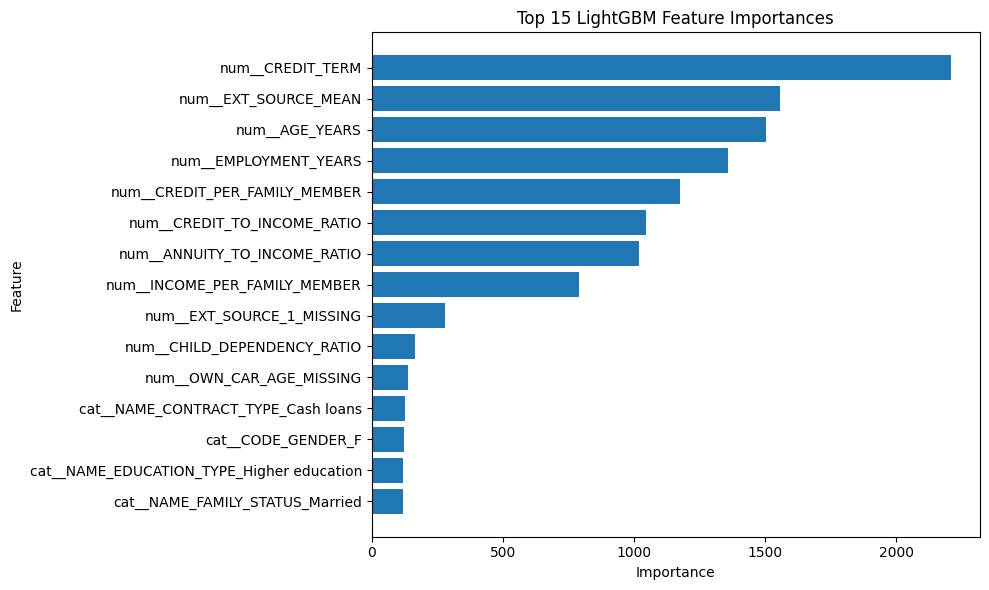

In [29]:
import matplotlib.pyplot as plt

top15 = importance_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"][::-1], top15["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")
plt.tight_layout()
plt.show()

---
## 16. Prediction Tool <a id='16'></a>

**What:** Wrap the trained LightGBM model in a predict_default_risk() function.
**Why:** This function is the Tool layer in the Agent pipeline. It accepts a dictionary of applicant data and returns a risk score and risk category.

In [40]:
def predict_default_risk(applicant_data: dict) -> dict:
    import pandas as pd
    import numpy as np

    applicant_df = pd.DataFrame([applicant_data])

    risk_score = float(lgbm_model.predict_proba(applicant_df)[0, 1])

    if risk_score < 0.30:
        risk_category = "Low Risk"
        recommended_action = "APPROVE"
    elif risk_score < 0.60:
        risk_category = "Medium Risk"
        recommended_action = "REVIEW"
    else:
        risk_category = "High Risk"
        recommended_action = "REJECT"

    applicant_processed = lgbm_model.named_steps["preprocessor"].transform(applicant_df)
    if hasattr(applicant_processed, "toarray"):
        applicant_dense = applicant_processed.toarray()
    else:
        applicant_dense = applicant_processed

    shap_vals = explainer.shap_values(applicant_dense)

    if isinstance(shap_vals, list):
        sv_single = shap_vals[1][0]
    elif hasattr(shap_vals, "todense"):
        sv_single = np.array(shap_vals.todense())[0]
    else:
        sv_single = shap_vals[0]

    feature_names = lgbm_model.named_steps["preprocessor"].get_feature_names_out()
    shap_series = pd.Series(sv_single, index=feature_names)
    top_factors = shap_series.nlargest(3).index.tolist()

    return {
        "risk_score": round(risk_score, 4),
        "risk_category": risk_category,
        "recommended_action": recommended_action,
        "top_risk_factors": top_factors
    }


In [41]:
# Test with first row of test set
sample_applicant = X_test.iloc[0].to_dict()
result = predict_default_risk(sample_applicant)
print(result)

{'risk_score': 0.0596, 'risk_category': 'Low Risk', 'recommended_action': 'APPROVE', 'top_risk_factors': ['num__EMPLOYMENT_YEARS', 'cat__ORGANIZATION_TYPE_Transport: type 4', 'cat__WEEKDAY_APPR_PROCESS_START_MONDAY']}


C:\Users\Kaustubh\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Kaustubh\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


---
## 17. SHAP Explainability <a id='17'></a>

**What:** Use SHAP TreeExplainer to compute per-feature contributions for the LightGBM model.
**Why:** SHAP values explain individual predictions -- essential for the Loan Underwriting Copilot to justify its decisions to underwriters.
**Expected:** A waterfall chart showing how each feature pushed a single applicant's risk score above or below the baseline.

In [33]:
import shap
import numpy as np

# Extract fitted LightGBM classifier from pipeline
lgbm_classifier = lgbm_model.named_steps["classifier"]

# Transform test data through preprocessor → dense array
X_test_processed = lgbm_model.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_dense = X_test_processed.toarray()
else:
    X_test_dense = X_test_processed

# Feature names after one-hot encoding
feature_names = lgbm_model.named_steps["preprocessor"].get_feature_names_out()

# Build explainer and compute SHAP on 200-sample subset (fast)
explainer = shap.TreeExplainer(lgbm_classifier)
sample = X_test_dense[:200]
shap_values = explainer.shap_values(sample)

# For binary classification, shap_values is a list [class_0, class_1]
# Use index 1 = default (positive) class
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = np.array(shap_values.todense()) if hasattr(shap_values, "todense") else shap_values

print("SHAP values shape:", sv.shape)
print("Features:", len(feature_names))


SHAP values shape: (200, 153)
Features: 153


C:\Users\Kaustubh\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


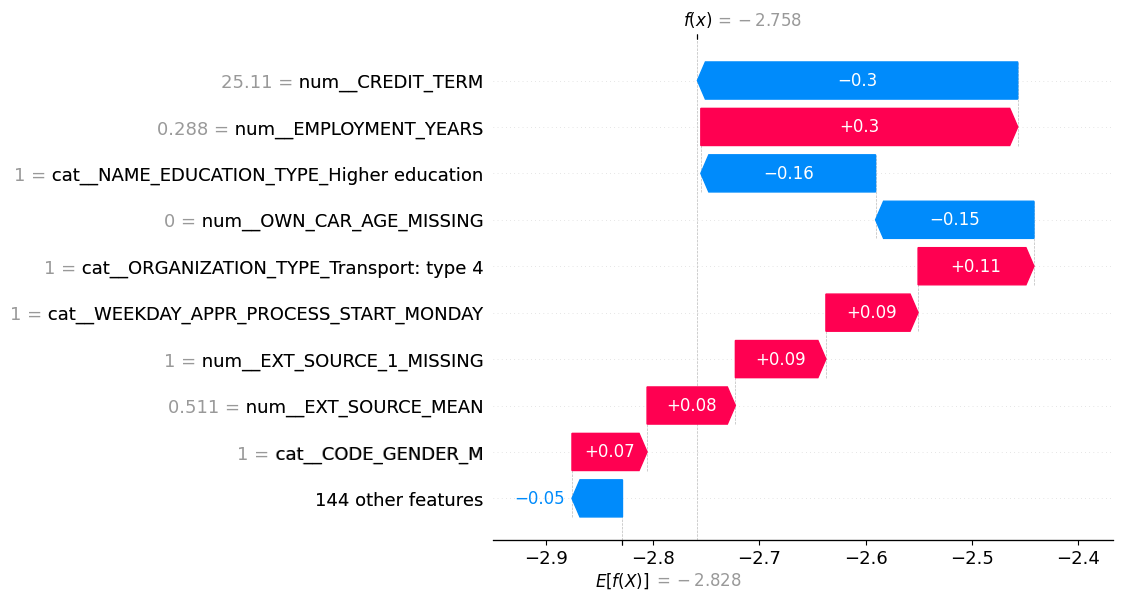

In [42]:
# Waterfall chart -- shows why applicant 0 got their score
sample_idx = 0

base_val = explainer.expected_value
if isinstance(base_val, list):
    base_val = base_val[1]

shap.plots.waterfall(
    shap.Explanation(
        values=sv[sample_idx],
        base_values=base_val,
        data=sample[sample_idx],
        feature_names=feature_names
    )
)

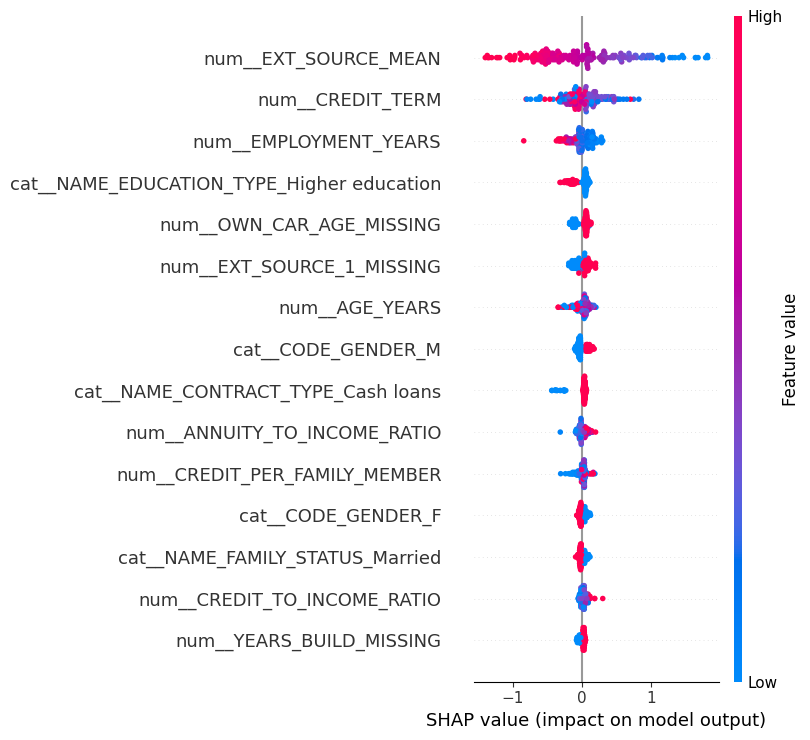

In [43]:
# Summary plot -- shows which features matter most overall
shap.summary_plot(sv, sample, feature_names=feature_names, max_display=15)

In [44]:
import joblib

# Save the trained LightGBM pipeline
joblib.dump(lgbm_model, "lgbm_pipeline.pkl")
print("Model saved: lgbm_pipeline.pkl")

Model saved: lgbm_pipeline.pkl


In [45]:
# Save model in LightGBM native format (version-independent)
lgbm_model.named_steps["classifier"].booster_.save_model("lgbm_booster.txt")
print("Booster saved as lgbm_booster.txt")

# Also save the preprocessor separately
import joblib
joblib.dump(lgbm_model.named_steps["preprocessor"], "preprocessor.pkl")
print("Preprocessor saved as preprocessor.pkl")


Booster saved as lgbm_booster.txt
Preprocessor saved as preprocessor.pkl


---
## 18. Key Findings <a id='18'></a>

### Class Imbalance
- The dataset is ~92% non-default / ~8% default.
- Accuracy is a misleading metric. ROC-AUC is used throughout this project.
- A dummy classifier predicting all 0s achieves 92% accuracy but 0.5 AUC.

### Missing Value Observations
- ~45 housing/property features have 47-70% missingness and weak correlation with TARGET. Excluded from the baseline.
- OWN_CAR_AGE (66% missing): Likely indicates no car. Captured via OWN_CAR_AGE_MISSING flag.
- EXT_SOURCE_1 (56% missing): Despite high missingness, it is one of the strongest predictors. Handled via EXT_SOURCE_MEAN + EXT_SOURCE_1_MISSING flag.
- DAYS_EMPLOYED anomaly: Sentinel value 365243 encodes 'unemployed'. Replaced with NaN for EMPLOYMENT_YEARS; captured separately in IS_UNEMPLOYED flag.

### Strongest Predictors

| Feature | Correlation with TARGET | Notes |
|---|---|---|
| EXT_SOURCE_MEAN | -0.222 | Strongest feature -- composite of 3 external scores |
| EXT_SOURCE_3 | -0.179 | Best individual external score |
| EXT_SOURCE_2 | -0.160 | |
| EXT_SOURCE_1 | -0.155 | 56% missing -- use via EXT_SOURCE_MEAN |
| AGE_YEARS | -0.078 | Older applicants default less |
| EMPLOYMENT_YEARS | -0.075 | Longer employment = lower risk |
| IS_UNEMPLOYED | +0.046 | Unemployed applicants are higher risk |
| REGION_RATING_CLIENT | +0.059 | Higher region risk rating = higher default |

### Engineered Features Created

| Feature | Formula | Purpose |
|---|---|---|
| AGE_YEARS | abs(DAYS_BIRTH) / 365 | Human-readable age |
| EMPLOYMENT_YEARS | abs(DAYS_EMPLOYED[!=365243]) / 365 | Job tenure |
| IS_UNEMPLOYED | DAYS_EMPLOYED == 365243 | Unemployment flag |
| CREDIT_TO_INCOME_RATIO | AMT_CREDIT / AMT_INCOME_TOTAL | Debt burden |
| ANNUITY_TO_INCOME_RATIO | AMT_ANNUITY / AMT_INCOME_TOTAL | Monthly repayment burden |
| CREDIT_TERM | AMT_CREDIT / AMT_ANNUITY | Implied loan duration (months) |
| CREDIT_PER_FAMILY_MEMBER | AMT_CREDIT / CNT_FAM_MEMBERS | Household credit exposure |
| INCOME_PER_FAMILY_MEMBER | AMT_INCOME_TOTAL / CNT_FAM_MEMBERS | Household income capacity |
| CHILD_DEPENDENCY_RATIO | CNT_CHILDREN / CNT_FAM_MEMBERS | Dependent burden |
| EXT_SOURCE_MEAN | mean(EXT_SOURCE_1/2/3) | Pooled external credit score |
| EXT_SOURCE_1_MISSING | EXT_SOURCE_1.isnull() | Informative missingness flag |
| OWN_CAR_AGE_MISSING | OWN_CAR_AGE.isnull() | Likely no car |
| YEARS_BUILD_MISSING | YEARS_BUILD_AVG.isnull() | Property info unavailable |

### Baseline Model Result

| Model | ROC-AUC | Notes |
|---|---|---|
| Logistic Regression | 0.684 | Baseline -- 29 features, stratified 80/20 split |

### Next Steps
1. Train LightGBM/XGBoost on the same feature set -- expected AUC improvement to ~0.74-0.78
2. Analyse feature importances from the gradient boosting model
3. Wrap the trained model in a predict_default_risk() tool function
4. Build the Agent layer that calls the tool from natural language input
5. Deploy as a Loan Underwriting Copilot